In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import torch 
import json
from src.config import CHECKPOINT_DIR
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def get_results(results_path):
    checkpoint_path = results_path / "best_model.pt"
    history_path = results_path / "history.csv"
    summary_path = results_path / "summary.csv"
    config_path = results_path / "config.json"

    with config_path.open("r", encoding="utf-8") as f:
        config = json.load(f)

    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    history = pd.read_csv(history_path)
    summary = pd.read_csv(summary_path)

    return history, summary, config, checkpoint

def plot_single_run(history, summary, checkpoint):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("final training accuracy:", summary["final_train_acc"][0])
    print("final validation accuracy:", summary["final_val_acc"][0])

    print("\nfinal training loss:", summary["final_train_loss"][0])
    print("final validation loss:", summary["final_val_loss"][0])

    print("best model training accuracy:", checkpoint["history"]["train_acc"][-1])
    print("best model validation accuracy:", checkpoint["history"]["val_acc"][-1])

    print("\nbest model training loss:", checkpoint["history"]["train_loss"][-1])
    print("best model validation loss:", checkpoint["history"]["val_loss"][-1])

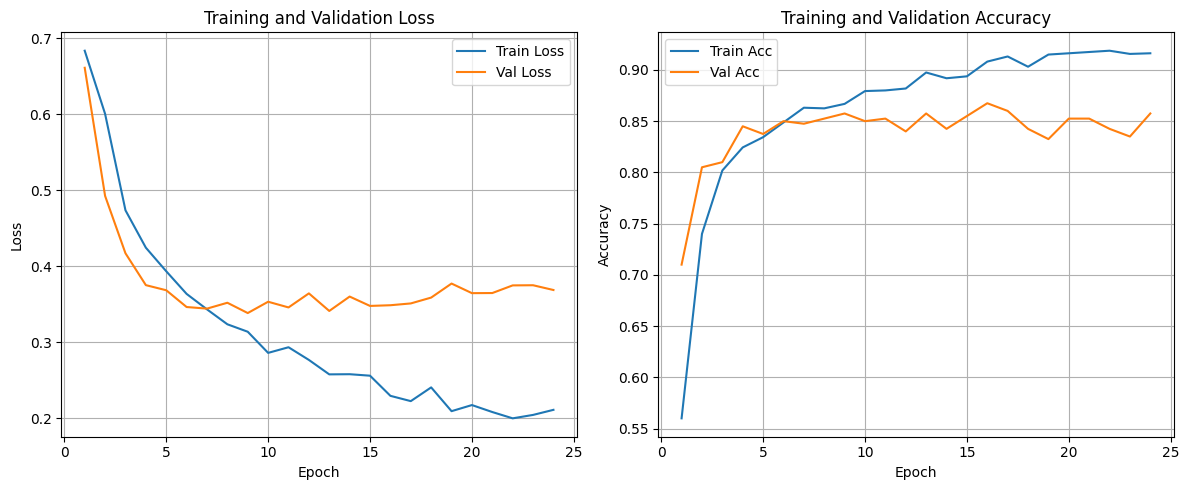

final training accuracy: 0.91625
final validation accuracy: 0.8575

final training loss: 0.2113446285901591
final validation loss: 0.3688553810771555
best model training accuracy: 0.908125
best model validation accuracy: 0.8675

best model training loss: 0.22975930779241024
best model validation loss: 0.34884327901527284


In [18]:
# FINAL CNN-LSTM MODEL!!!!!!
results_path = CHECKPOINT_DIR / "CNN_LSTM_V4" / "final_systematic_search_2" / "h64_d0.3_wd0_ls0.0"
history, summary, _, checkpoint = get_results(results_path)
plot_single_run(history, summary, checkpoint)

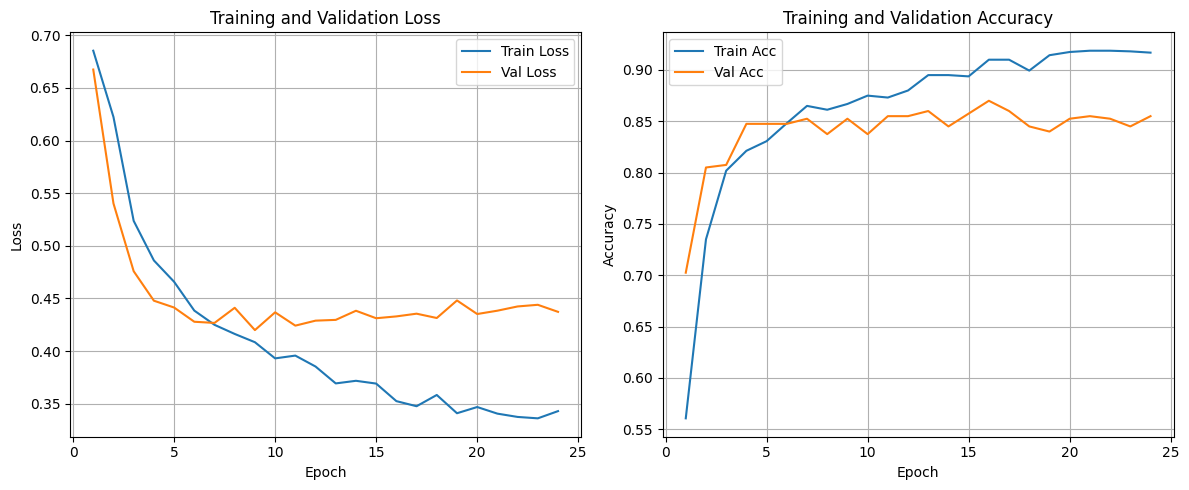

final training accuracy: 0.916875
final validation accuracy: 0.855

final training loss: 0.3430427887290716
final validation loss: 0.4373041269183159
best model training accuracy: 0.91
best model validation accuracy: 0.87

best model training loss: 0.3525352642685175
best model validation loss: 0.4329807314276695


In [4]:
# FINAL CNN-LSTM MODEL!!!!!!
results_path = CHECKPOINT_DIR / "CNN_LSTM_V4" / "final_systematic_search_2" / "h64_d0.35_wd2e-05_ls0.1"
history, summary, _, checkpoint = get_results(results_path)
plot_single_run(history, summary, checkpoint)

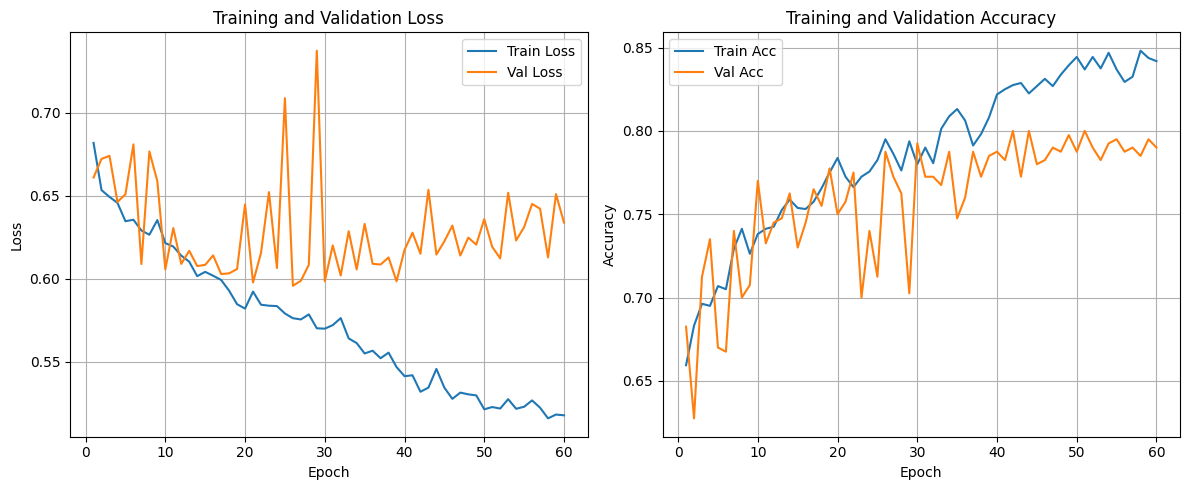

final training accuracy: 0.841875
final validation accuracy: 0.79

final training loss: 0.5177845768630505
final validation loss: 0.6338128438591957
best model training accuracy: 0.8275
best model validation accuracy: 0.8

best model training loss: 0.5319605186581612
best model validation loss: 0.6149996390938759


In [20]:
results_path = CHECKPOINT_DIR / "STGCN_V1" / "final_seed_search_updated_masked_bn" / "final_seed42"
history, summary, _, checkpoint = get_results(results_path)
plot_single_run(history, summary, checkpoint)